# Table of Content

- [1. Introduction](#1-introduction)
  - [1.1 Problem Statement](#11-problem-statement)
  - [1.2 Dataset](#12-dataset)
- [2. Methodology](#2-methodology)
  - [2.1 Data Preprocessing](#21-data-preprocessing)
  - [2.2 Data Analysis](#22-data-analysis)
- [3. Modelling](#3-modelling)
  - [3.1 Linear Regression](#31-Linear-Regression)
  - [3.2 Ridge Regression](#32-Ridge-Regression)
  - [3.3 LASSO Regression](#33-LASSO-Regression)
  - [3.4 Decision Tree Regression](#34-Decision-Tree-Regression)
- [4. Evaluation](#4-evaluation)
  - [4.1 Model Performance Comparison](#41-Model-Performance-Comparison)
  - [4.2 Model Optimization with ML Method](#42-Model-Optimization-with-ML-Method)
    - [4.2.1 Hyperparameter Tuning for Ridge and Lasso Regression](#421-LHyperparameter-Tuning-for-Ridge-and-Lasso-Regression)
    - [4.2.2 Hyperparameter Tuning for Decision Tree Regression](#422-Hyperparameter-Tuning-for-Decision-Tree-Regression)
- [5. Conclusion and Future Work](#5-conclusion-and-future-work)

# 1. Introduction



## 1.1 Problem Statement

Using 731 records of daily data from 2011 to 2012—including various features related to time, weather, and user behavior that may affect rental activity, along with actual bike rental count labels—predict the daily number of bike rentals in Washington D.C.’s Capital Bikeshare system.

## 1.2 Dataset

In [1]:
# Import Libraries
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
# preprocessing and metrics
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_squared_log_error, make_scorer


In [5]:

# Create a df describing each variable
variables = [
    "instant", "dteday", "season", "yr", "mnth", "hr", "holiday",
    "weekday", "workingday", "weathersit", "temp", "atemp", "hum",
    "windspeed", "casual", "registered", "cnt"
]

descriptions = [
    "Record index",
    "Date of the observation",
    "Season (1: Spring, 2: Summer, 3: Fall, 4: Winter)",
    "Year (0: 2011, 1: 2012)",
    "Month (1 to 12)",
    "Hour (0 to 23) – not available in day.csv",
    "Indicator if the day is a holiday (1: holiday, 0: not)",
    "Day of the week (0: Sunday to 6: Saturday)",
    "Indicator if day is working day (1) or weekend/holiday (0)",
    "Weather situation (1: Clear/Few clouds, 2: Mist/Cloudy, 3: Light Snow/Rain, 4: Heavy Rain/Snow)",
    "Normalized temperature in Celsius (divided by 41)",
    "Normalized feeling temperature in Celsius (divided by 50)",
    "Normalized humidity (divided by 100)",
    "Normalized wind speed (divided by 67)",
    "Count of casual users (leisure)",
    "Count of registered users (subscribers)",
    "Total count of bike rentals (casual + registered)"
]

df_variables = pd.DataFrame({
    "Variable": variables,
    "Description": descriptions
})


df_variables.head(18)

,Variable,Description
0,instant,Record index
1,dteday,Date of the observation
2,season,"Season (1: Spring, 2: Summer, 3: Fall, 4: Winter)"
3,yr,"Year (0: 2011, 1: 2012)"
4,mnth,Month (1 to 12)
5,hr,Hour (0 to 23) – not available in day.csv
6,holiday,"Indicator if the day is a holiday (1: holiday,..."
7,weekday,Day of the week (0: Sunday to 6: Saturday)
8,workingday,Indicator if day is working day (1) or weekend...
9,weathersit,"Weather situation (1: Clear/Few clouds, 2: Mis..."


In [6]:
# Load the dataset from 'day.csv' into the DataFrame
day_bike = pd.read_csv('day.csv')
day_bike.head(10)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
5,6,2011-01-06,1,0,1,0,4,1,1,0.204348,0.233209,0.518261,0.089565,88,1518,1606
6,7,2011-01-07,1,0,1,0,5,1,2,0.196522,0.208839,0.498696,0.168726,148,1362,1510
7,8,2011-01-08,1,0,1,0,6,0,2,0.165000,0.162254,0.535833,0.266804,68,891,959
8,9,2011-01-09,1,0,1,0,0,0,1,0.138333,0.116175,0.434167,0.361950,54,768,822
9,10,2011-01-10,1,0,1,0,1,1,1,0.150833,0.150888,0.482917,0.223267,41,1280,1321


In [7]:
# Display dataset structure info, quickly check data completeness  
day_bike.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [8]:
# Show statistics of numeric fields, quickly understand data distribution
day_bike.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [9]:
# One-click overview of the dataset to quickly understand overall data quality
def enhanced_data_overview(df, head_rows=5):
    """
    Displays an extended overview of the DataFrame:
    - Shape (rows, columns)
    - Memory usage
    - Missing values (count + percentage)
    - Duplicate rows
    - Data types
    - Number of unique values per column
    - Head (first rows)
    - Descriptive statistics for numeric features
    - Descriptive statistics for categorical features
    """
    # 1. Shape
    display(Markdown("## Shape"))
    print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")
    
    # 2. Memory Usage
    display(Markdown("## Memory Usage"))
    mem_usage = df.memory_usage(deep=True).sum() / (1024 ** 2)
    print(f"Total Memory Usage: {mem_usage:.2f} MB\n")
    
    # 3. Missing Values
    display(Markdown("## Missing Values"))
    missing = pd.DataFrame({
        'Missing Count': df.isnull().sum(),
        'Missing %': (df.isnull().mean() * 100).round(2)
    })
    display(missing)
    
    # 4. Duplicate Rows
    display(Markdown("## Duplicate Rows"))
    dup_count = df.duplicated().sum()
    print(f"Number of duplicate rows: {dup_count}\n")
    
    # 5. Data Types
    display(Markdown("## Data Types"))
    display(pd.DataFrame(df.dtypes, columns=['Dtype']))
    
    # 6. Unique Values Count
    display(Markdown("## Unique Values per Column"))
    unique_counts = pd.DataFrame({
        'Unique Count': df.nunique(),
        'Data Type': df.dtypes
    })
    display(unique_counts)

    # 7. Head (first rows)
    display(Markdown("## Head (First Rows)"))
    display(df.head(head_rows))

    # 8. Bottom (last rows)
    display(Markdown("## Bottom (Last Rows)"))
    display(df.tail(head_rows))

    #9. Descriptive Statistics
    display(Markdown("## Descriptive Statistics"))
    display(df.describe(include='all'))

# Call the function to display the overview
enhanced_data_overview(day_bike, head_rows=5)

## Shape

Rows: 731, Columns: 16



## Memory Usage

Total Memory Usage: 0.12 MB



## Missing Values

...

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


## Bottom (Last Rows)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796
730,731,2012-12-31,1,1,12,0,1,1,2,0.215833,0.223487,0.577500,0.154846,439,2290,2729


## Descriptive Statistics

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
unique,NaN,731,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,2011-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,366.000000,NaN,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,NaN,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,NaN,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,NaN,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,NaN,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000


# 2. Methodology

## 2.1 Data Preprocessing

In [10]:
def extract_features_categorical(df, cat_th = 13, num_th = 20):
    """
    Extracts categorical features from the DataFrame based on thresholds for unique values.
    
    Parameters:
    - df: DataFrame to extract features from
    - cat_th: Threshold for categorical features (default 13)
    - num_th: Threshold for numerical features (default 20)
    
    Returns:
    - cat_cols: List of categorical feature names
    - num_cols: List of numerical feature names
    """
    # 1. Identify 'true' categorical columns
    cat_cols = [col for col in df.columns if df[col].dtype == "O"]

    # 2. Identify numeric columns that should be treated as categorical
    #    because they have fewer than cat_th unique values
    num_but_cat = [
        col for col in df.columns
        if df[col].nunique() < cat_th and df[col].dtypes != "O"
    ]
    # 3. Identify 'categorical but high cardinality' columns
    cat_but_car = [
        col for col in df.columns
        if df[col].nunique() > cat_th and df[col].dtypes == "O"
    ]
    # 4. Combine object-type categorical columns and numeric-but-categorical columns,
    #    then exclude any high-cardinality columns
    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    # 5. Identify numeric columns (dtype != object), excluding those in num_but_cat
    num_cols = [col for col in df.columns if df[col].dtype != "O"]
    num_cols = [col for col in num_cols if col not in num_but_cat]

    # 6. Identify binary categorical columns (exactly two unique values)
    binary_cols = [col for col in cat_cols if df[col].nunique() == 2]

    # 7. Identify non-binary categorical columns
    only_cat_cols = list(set(cat_cols) - set(binary_cols))

    
    return cat_cols, num_cols

In [11]:
# Renaming columns for better readability 
day_bike.rename(columns={
    'yr': 'year',
    'mnth': 'month',
    'hr': 'hour',
    'temp': 'temperature',
    'atemp': 'feeling_temperature',
    'hum': 'humidity',
    'cnt': 'total_count',
    'dteday': 'date',

}, inplace=True)
# Display the first few rows of the modified DataFrame
day_bike.head()

,instant,date,season,year,month,holiday,weekday,workingday,weathersit,temperature,feeling_temperature,humidity,windspeed,casual,registered,total_count
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [12]:
categorical_variables, numerical_variables = extract_features_categorical(day_bike, cat_th=13, num_th=20)

# Display the categorical and numerical variables
print("Categorical Variables:")
print(categorical_variables)

print("\nNumerical Variables:")
print(numerical_variables)


Categorical Variables:
['season', 'year', 'month', 'holiday', 'weekday', 'workingday', 'weathersit']

Numerical Variables:
['instant', 'temperature', 'feeling_temperature', 'humidity', 'windspeed', 'casual', 'registered', 'total_count']


## 2.2 Data Analysis

## Descriptive Statistics for Numerical Features

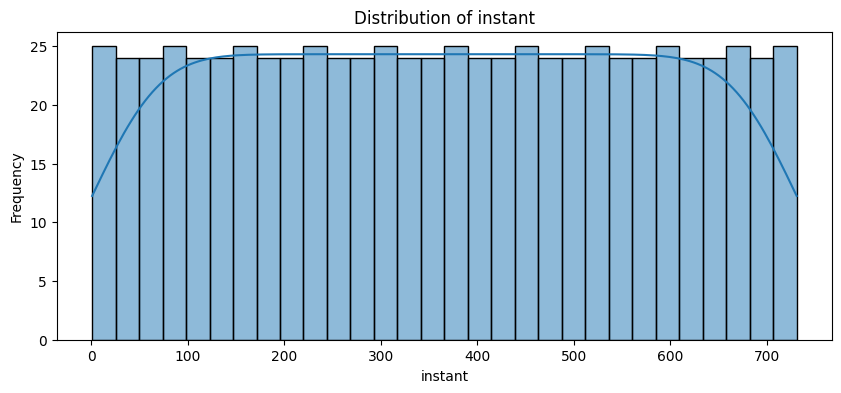

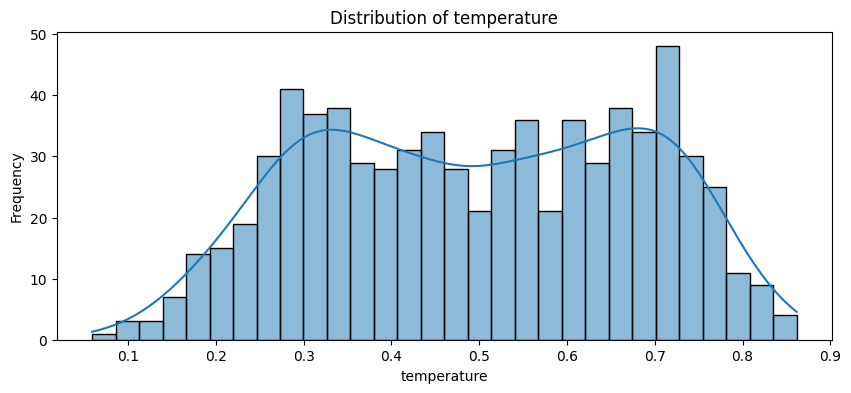

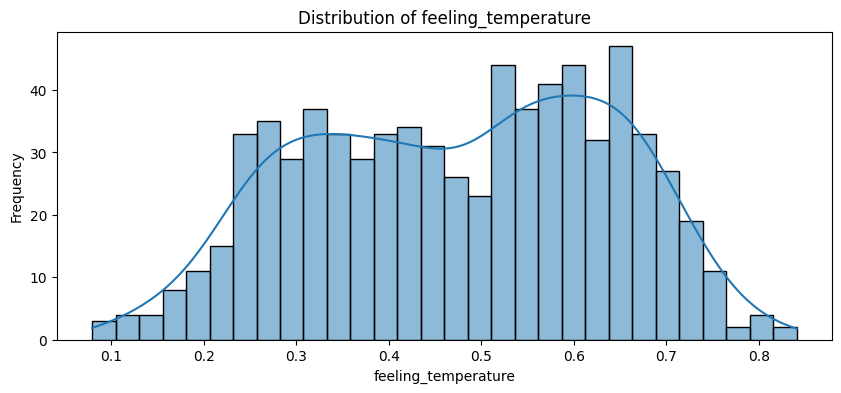

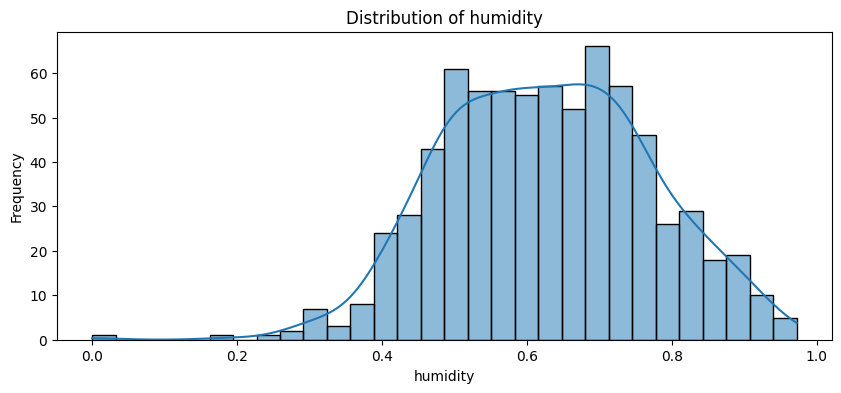

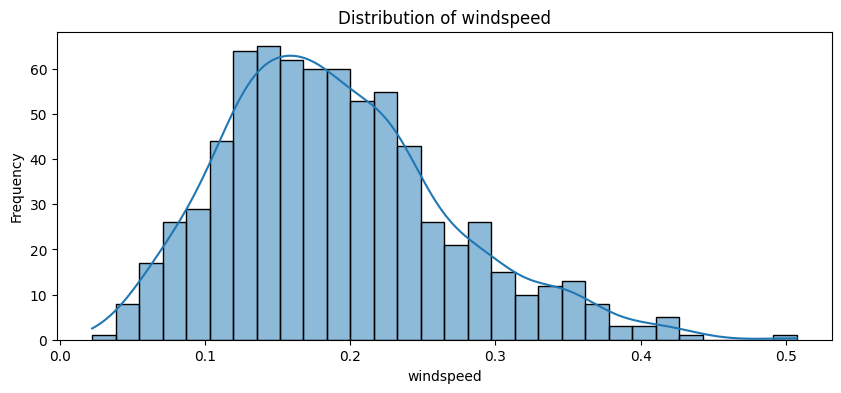

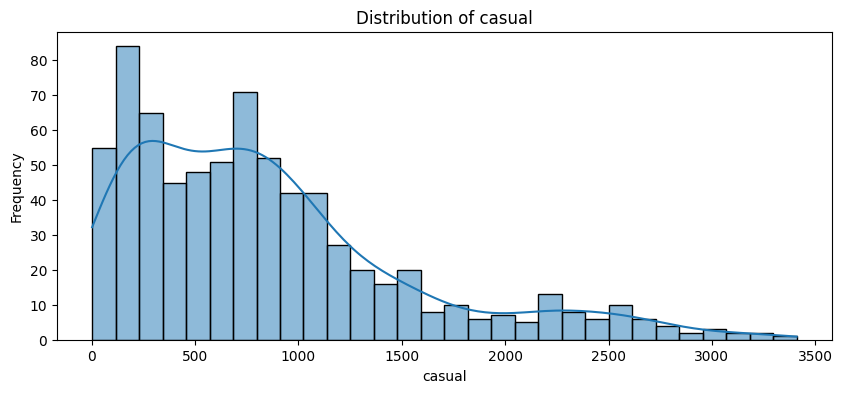

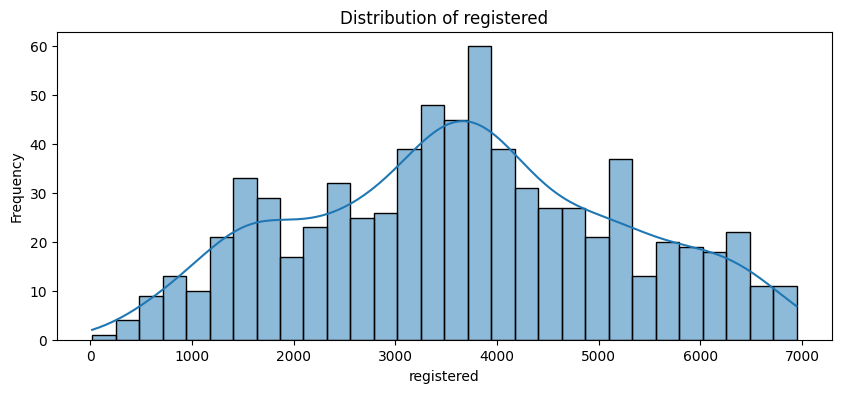

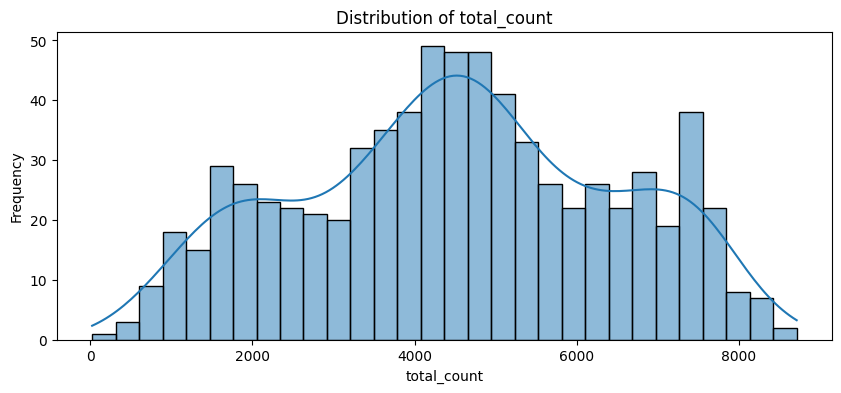

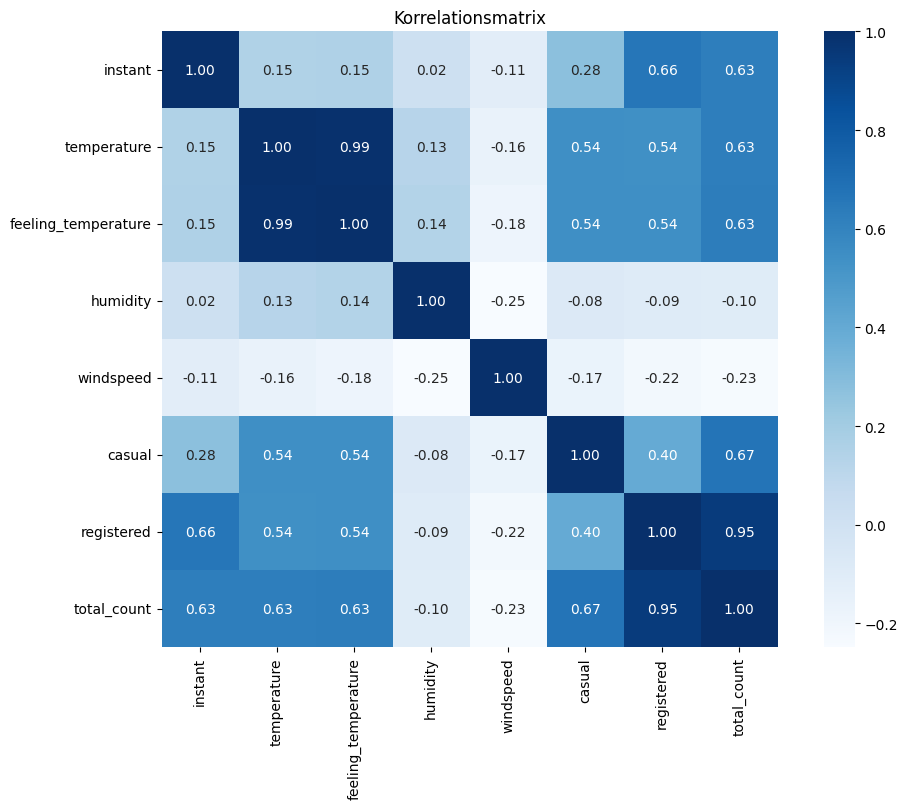

In [13]:
# TODO:
# 1. Alyse numerical variables
# 2. Visualize categorical variables
def analyze_numerical_features(df, numerical_features):
    """
    Analyzes numerical features in the DataFrame:
    - Displays descriptive statistics
    - Visualizes distributions and correlations
    """
    # Descriptive statistics
    display(Markdown("## Descriptive Statistics for Numerical Features"))
   

    # Visualize distributions of numerical features
    for feature in numerical_features:
        plt.figure(figsize=(10, 4))
        sns.histplot(df[feature], kde=True, bins=30)
        plt.title(f'Distribution of {feature}')
        plt.xlabel(feature)
        plt.ylabel('Frequency')
        plt.show()

# Analyze numerical features
analyze_numerical_features(day_bike, numerical_variables)

# Korrelationsmatrix (Heatmap) mit blauen Farben
def plot_correlation_matrix(df, numerical_features):    
    """
    Plots a correlation matrix heatmap for numerical features in the DataFrame.
    
    Parameters:
    - df: DataFrame containing the data
    - numerical_features: List of numerical feature names
    """
    plt.figure(figsize=(12, 8))
    corr_matrix = df[numerical_features].corr()
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='Blues', square=True)
    plt.title('Korrelationsmatrix')
    plt.show()

# Plot the correlation matrix
plot_correlation_matrix(day_bike, numerical_variables)

## Analysis of Categorical Variables

### Feature: season

season
3    188
2    184
1    181
4    178
Name: count, dtype: int64

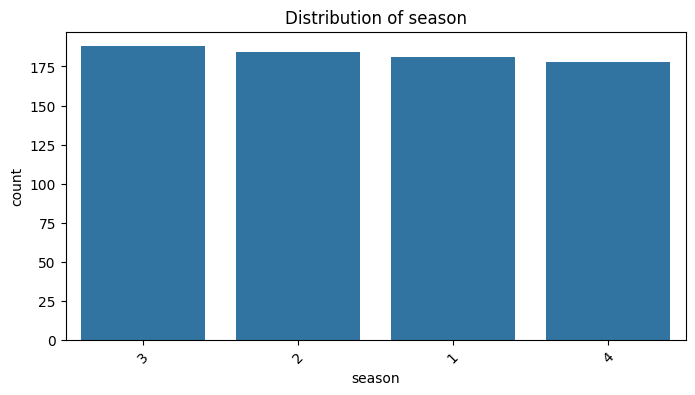

**Average total_count by season:**

season
3    5644.303191
2    4992.331522
4    4728.162921
1    2604.132597
Name: total_count, dtype: float64

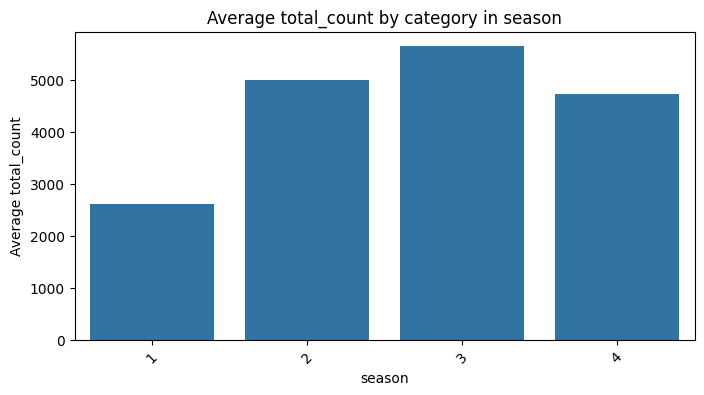

### Feature: year

year
1    366
0    365
Name: count, dtype: int64

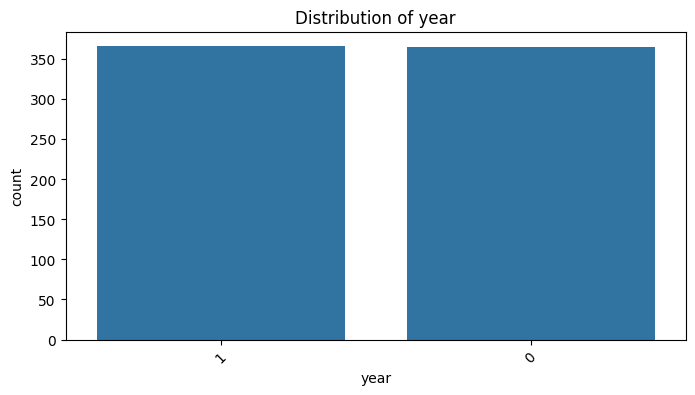

**Average total_count by year:**

year
1    5599.934426
0    3405.761644
Name: total_count, dtype: float64

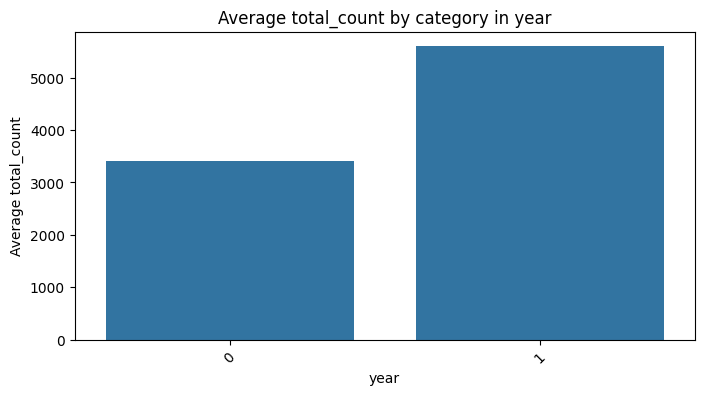

### Feature: month

month
1     62
3     62
7     62
5     62
12    62
10    62
8     62
4     60
9     60
6     60
11    60
2     57
Name: count, dtype: int64

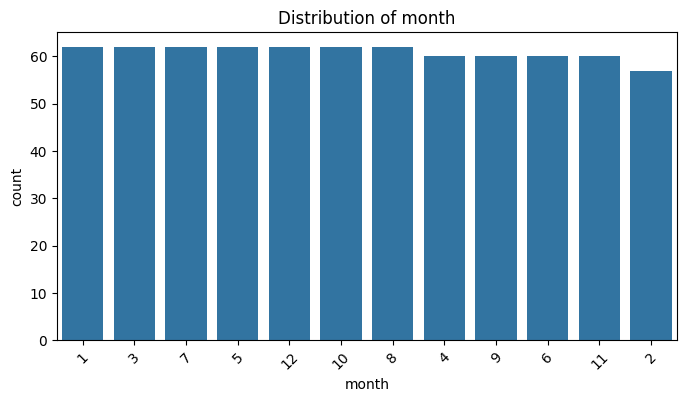

**Average total_count by month:**

month
6     5772.366667
9     5766.516667
8     5664.419355
7     5563.677419
5     5349.774194
10    5199.225806
4     4484.900000
11    4247.183333
3     3692.258065
12    3403.806452
2     2655.298246
1     2176.338710
Name: total_count, dtype: float64

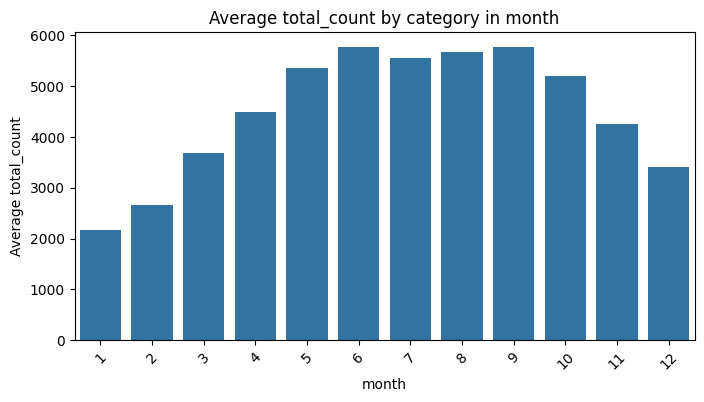

### Feature: holiday

holiday
0    710
1     21
Name: count, dtype: int64

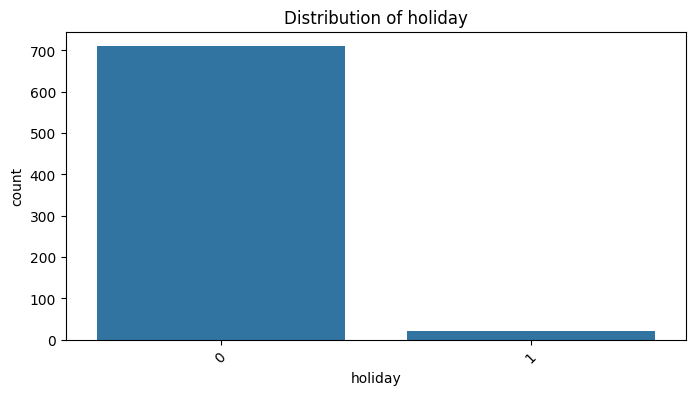

**Average total_count by holiday:**

holiday
0    4527.104225
1    3735.000000
Name: total_count, dtype: float64

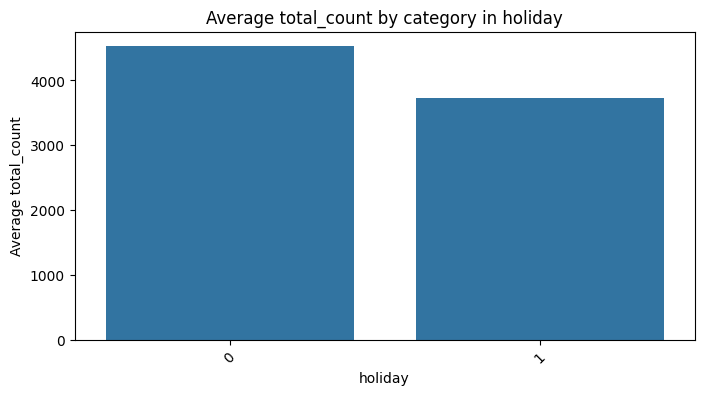

### Feature: weekday

weekday
6    105
0    105
1    105
2    104
3    104
4    104
5    104
Name: count, dtype: int64

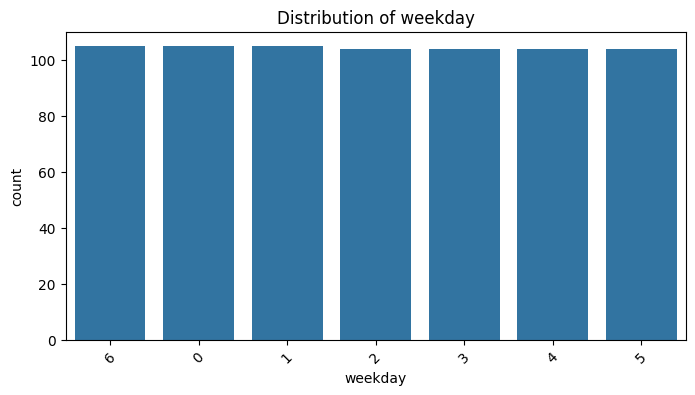

**Average total_count by weekday:**

weekday
5    4690.288462
4    4667.259615
6    4550.542857
3    4548.538462
2    4510.663462
1    4338.123810
0    4228.828571
Name: total_count, dtype: float64

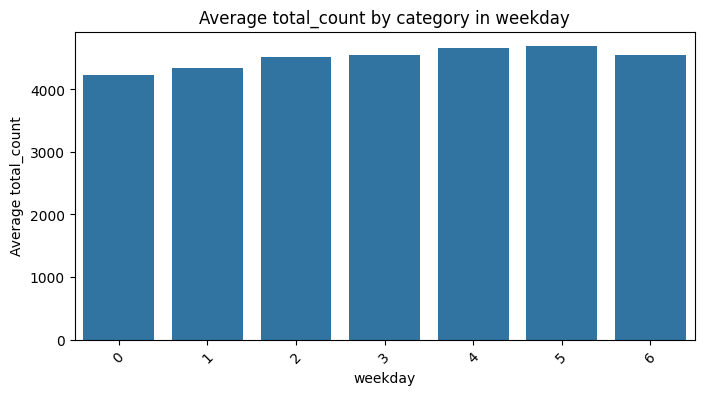

### Feature: workingday

workingday
1    500
0    231
Name: count, dtype: int64

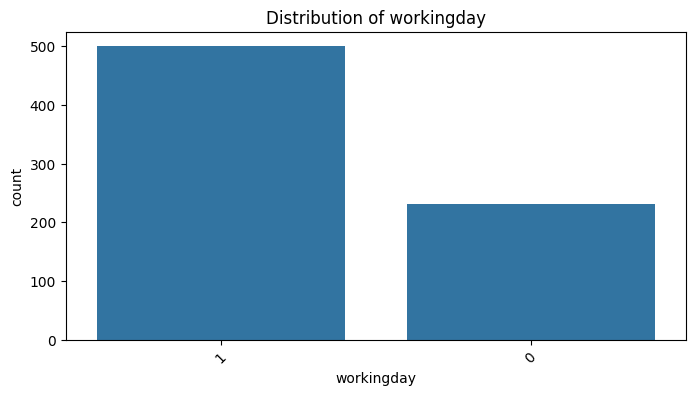

**Average total_count by workingday:**

workingday
1    4584.820000
0    4330.168831
Name: total_count, dtype: float64

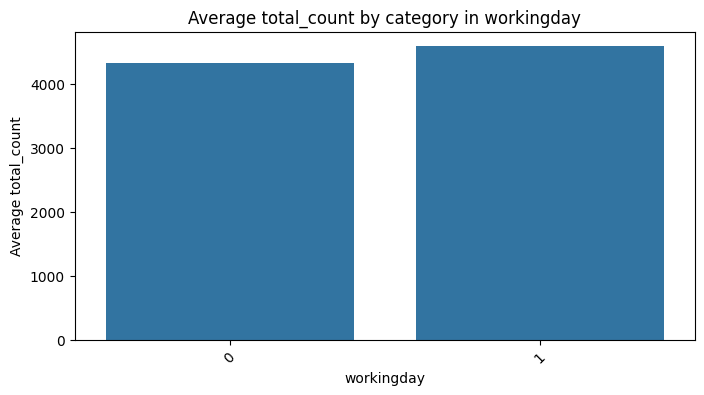

### Feature: weathersit

weathersit
1    463
2    247
3     21
Name: count, dtype: int64

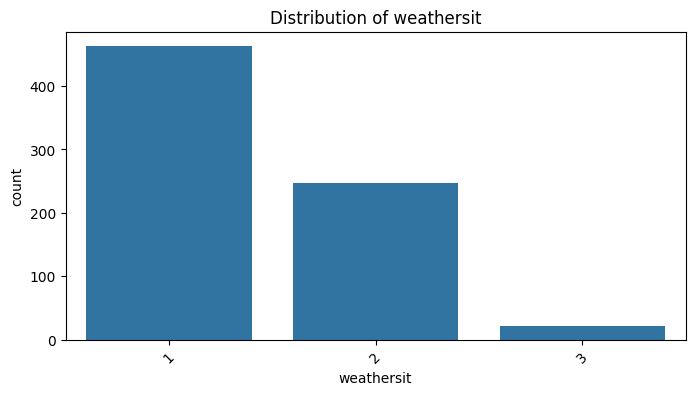

**Average total_count by weathersit:**

weathersit
1    4876.786177
2    4035.862348
3    1803.285714
Name: total_count, dtype: float64

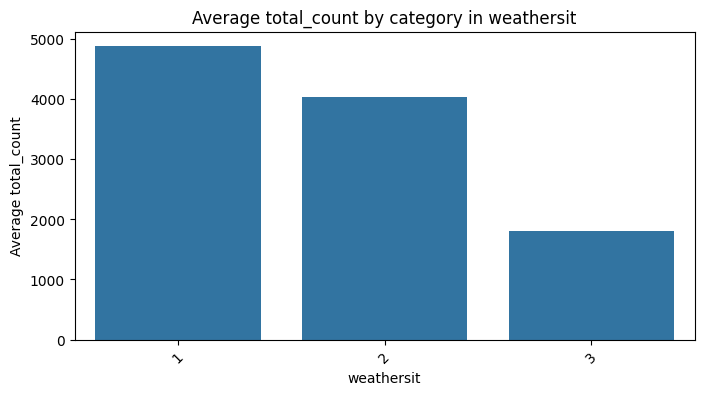

In [14]:
# New Cell: Analysis of Categorical Variables
from IPython.display import display, Markdown

def analyze_categorical_features(df, cat_features, target=None):
    """
    Analyzes categorical variables:
    - Displays frequency distributions
    - Plots countplots for each feature
    - (Optional) Aggregates by feature and calculates the mean of the target variable
    """
    display(Markdown("## Analysis of Categorical Variables"))
    
    for feature in cat_features:
        display(Markdown(f"### Feature: {feature}"))
        
        # Display the frequency distribution
        counts = df[feature].value_counts()
        display(counts)
        
        # Create a countplot
        plt.figure(figsize=(8, 4))
        sns.countplot(x=feature, data=df, order=counts.index)
        plt.title(f'Distribution of {feature}')
        plt.xticks(rotation=45)
        plt.show()
        
        # Optional analysis: aggregate target variable if provided
        if target is not None and target in df.columns:
            group_stats = df.groupby(feature)[target].mean().sort_values(ascending=False)
            display(Markdown(f"**Average {target} by {feature}:**"))
            display(group_stats)
            plt.figure(figsize=(8, 4))
            sns.barplot(x=group_stats.index, y=group_stats.values)
            plt.title(f'Average {target} by category in {feature}')
            plt.xticks(rotation=45)
            plt.ylabel(f'Average {target}')
            plt.show()

# Calling the function with your categorical variables
analyze_categorical_features(day_bike, categorical_variables, target="total_count")

# 3. Modeling  

Modeling Strategy：

In this section, we define the machine learning task and modeling approach used in the project.

The target variable in this dataset is `total_count`, which represents the total number of bike rentals per day. Since `total_count` is a continuous numerical value rather than a category or label, the task is defined as a **regression problem**.

We will choose and compare the performance of four regression models。Each model builds upon or differs from the previous one in specific ways :

- **Linear Regression**: A baseline model assuming a linear relationship between features and target. Simple and interpretable but limited in capturing complex patterns.

- **Ridge Regression**: Extends linear regression with L2 regularization (penalty on the squared magnitude of coefficients) to prevent overfitting, especially when features are many or correlated. Controls complexity better than Linear Regression.

- **Lasso Regression**: Similar to Ridge but uses L1 regularization (penalty on the absolute value of coefficients). Besides reducing overfitting, it can set some coefficients to zero, performing automatic feature selection which Ridge cannot.

- **Decision Tree Regression**: A non-linear model that splits data based on decision rules rather than fitting a linear equation. Captures complex interactions but may overfit without pruning or regularization.

All models will be trained on the training set and make predictions on the test set.

## 3.1 Linear Regression

In [44]:
# Data Preparation 
# Define target and features
target_variable = 'total_count'
feature_variables = pd.Index(numerical_variables).drop(['casual', 'registered', 'total_count']).tolist()

# Import train_test_split 
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets (80%/20%)
X = day_bike[feature_variables]
y = day_bike[target_variable]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
# Linear Regression Pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

linear_pipeline = Pipeline([('scaler', StandardScaler()), ('regressor', LinearRegression())])

In [46]:
#Training and Prediction
# Train the model on the training data
linear_pipeline.fit(X_train, y_train)

# Make predictions on the test data
y_pred_lr = linear_pipeline.predict(X_test)

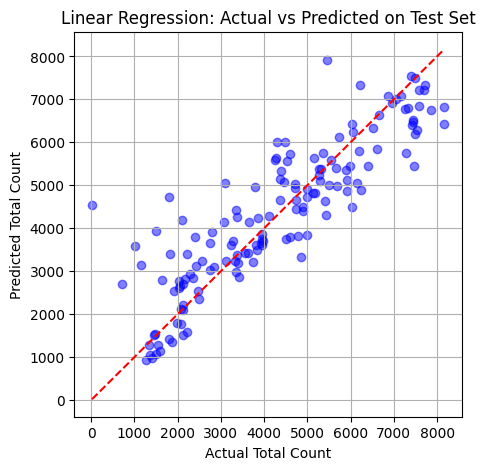

In [47]:
import matplotlib.pyplot as plt

#Linear Regression: Visualize Actual vs. Predicted Values on Test Set
plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') 
plt.xlabel('Actual Total Count')
plt.ylabel('Predicted Total Count')
plt.title('Linear Regression: Actual vs Predicted on Test Set')
plt.grid(True)
plt.show()

## 3.2 Ridge Regression

In [48]:
from sklearn.linear_model import Ridge

# Ridge (with scaling)
# Using default hyperparameters, alpha=1.0 (will be tuned with GridSearchCV in Chapter 4)
ridge_pipeline = Pipeline([('scaler', StandardScaler()), ('regressor', Ridge())])

ridge_pipeline.fit(X_train, y_train)
y_pred_ridge = ridge_pipeline.predict(X_test)

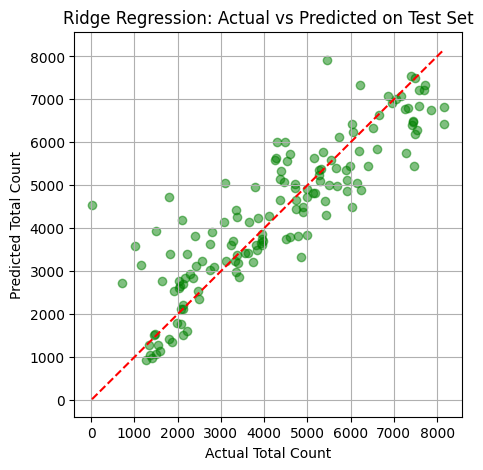

In [49]:
#Ridge Regression: Visualize Actual vs. Predicted Values on Test Set
plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred_ridge, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Total Count')
plt.ylabel('Predicted Total Count')
plt.title('Ridge Regression: Actual vs Predicted on Test Set')
plt.grid(True)
plt.show()

## 3.3 LASSO Regression

In [50]:
from sklearn.linear_model import Lasso

# Lasso (with scaling)
# Using default hyperparameters, alpha=1.0 (will be tuned with GridSearchCV in Chapter 4)
lasso_pipeline = Pipeline([('scaler', StandardScaler()), ('regressor', Lasso())])

lasso_pipeline.fit(X_train, y_train)
y_pred_lasso = lasso_pipeline.predict(X_test)

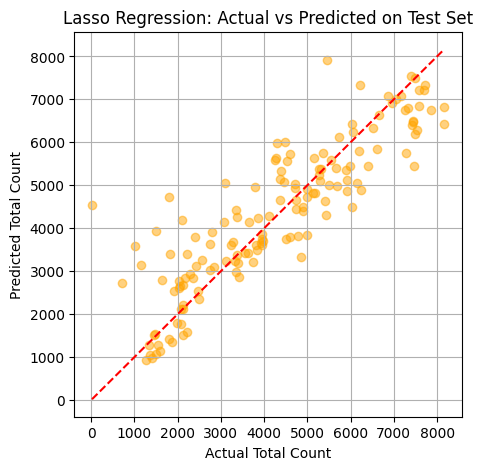

In [51]:
#Lasso Regression: Visualize Actual vs. Predicted Values on Test Set
plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred_lasso, alpha=0.5, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Total Count')
plt.ylabel('Predicted Total Count')
plt.title('Lasso Regression: Actual vs Predicted on Test Set')
plt.grid(True)
plt.show()

## 3.4 Decision Tree Regression

In [52]:
from sklearn.tree import DecisionTreeRegressor

# Decision Tree (no scaling)
# Using default parameters like max_depth=None (to be tuned with GridSearchCV in Chapter 4)
tree_pipeline = Pipeline([('regressor', DecisionTreeRegressor(random_state=42))])

tree_pipeline.fit(X_train, y_train)
y_pred_tree = tree_pipeline.predict(X_test)

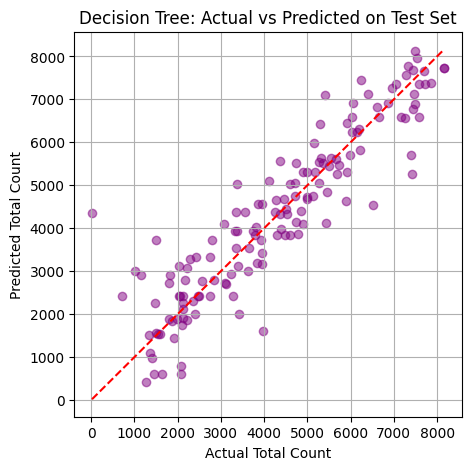

In [53]:
#Decision Tree: Visualize Actual vs. Predicted Values on Test Set
plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred_tree, alpha=0.5, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Total Count')
plt.ylabel('Predicted Total Count')
plt.title('Decision Tree: Actual vs Predicted on Test Set')
plt.grid(True)
plt.show()

**Note on Hyperparameter**: 

In this chapter, all models are trained using default or manually specified parameters without hyperparameter tuning. The purpose is to establish baseline performances for each regression approach under consistent conditions. By doing so, we can later assess whether tuning the models actually improves their predictive ability.

Hyperparameter optimization, such as using `GridSearchCV`, is intentionally deferred to the evaluation stage in Chapter 4. This two-step modeling strategy helps maintain a clear separation between initial modeling and performance optimization, and supports fair and interpretable model comparison.

# 4. Model Evaluation  

Model Evaluation Strategy：

In this section, we evaluate the four regression models using three widely recognized metrics, each providing complementary insights into the model's performance:

- **MAE** (Mean Absolute Error): Reflects the average magnitude of errors between predicted and actual values, expressed in the same unit as the target variable, making it highly interpretable. It is insensitive to outliers and suitable for scenarios where large errors are not severe.

- **RMSE** (Root Mean Squared Error): Also shares the same unit as the target variable but penalizes larger errors more heavily than MAE. It is useful for assessing whether the model remains robust under extreme conditions.

- **R²** (Coefficient of Determination): Indicates the proportion of variance in the target variable explained by the model. As a unitless metric, it facilitates comparison between models and reflects the overall goodness of fit.

All these metrics are computed on the test set to assess the predictive accuracy and generalization ability of each model.

To further improve model performance, we apply machine learning techniques by performing hyperparameter tuning with GridSearchCV using cross-validation. This prevents overfitting and ensures that the chosen hyperparameters are robust across data subsets:

- **Decision Tree Regression**:Tuned parameters include `max_depth` (to control tree complexity) and `min_samples_split` (to prevent overly fine splits).

- **Ridge and Lasso Regression**: Tuned hyperparameter is `alpha`, the regularization strength, to balance underfitting and overfitting.

These steps help effectively prevent overfitting and ensure better model generalization.

## 4.1  Model Performance Comparison

In [ ]:
#Compute evaluation metrics (MAE, RMSE, R²) of all models on the test set (pipeline)
#Visualize model performances in tables or plots
#Analyze strengths and weaknesses of each model based on metrics

## 4.2 Model Optimization with ML Method

### 4.2.1 Hyperparameter Tuning for Ridge and Lasso Regression

In [ ]:
#Use GridSearchCV with cross-validation for hyperparameter tuning 
#Tune regularization parameter alpha for Ridge and Lasso regression
#Retrain models with optimal parameters and re-evaluate on the test set 
#Compare performance before and after tuning to assess improvement 
#Explain how tuning enhances generalization and reduces overfitting  

### 4.2.2 Hyperparameter Tuning for Decision Tree Regression

In [ ]:
#Use GridSearchCV with cross-validation for hyperparameter tuning 
#Tune Decision Tree parameters such as max_depth and min_samples_split
#Retrain models with optimal parameters and re-evaluate on the test set 
#Compare performance before and after tuning to assess improvement 
#Explain how tuning enhances generalization and reduces overfitting  

# 5 Conclusion and Future Outlook